# Estudio comparativo de algoritmos y distribuciones del bandido de k-brazos

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo $\epsilon$-greedy con brazos cuya recompensa viene dada por una función de distribución normal.

## Constantes

In [7]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/comparison"

## Librerías

In [8]:
import sys
import random
import numpy as np

sys.path.append('./src')

from arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from experiment import run_experiment
from algorithms import EpsilonGreedy, UCB1, SoftMax
from plotting import plot_average_rewards, plot_optimal_selections

## Reproducibilidad

In [9]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Para comparar los algoritmos, se ha tomado la variante que mejores resultados ha obtenido de cada familia en los experimentos individuales. Para compararlos se ha decidido tomar las gráficas de recompensa promedio y de porcentaje de selecciones óptimas. Con la primera se puede comprobar la eficacia de los algoritmos a la hora de conseguir la mayor recompensa posible y en la segunda su capacidad de separar el brazo óptimo de los demás, especialmente en aquellos casos donde los mejores brazos tienen recompensas muy similares y todos obtienen resultados parecidos en sus recompensas promedio.

### Distribución normal

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1), ArmNormal(mu=2.4, sigma=1), ArmNormal(mu=1.19, sigma=1), ArmNormal(mu=4.37, sigma=1), ArmNormal(mu=6.39, sigma=1), ArmNormal(mu=7.59, sigma=1), ArmNormal(mu=8.8, sigma=1), ArmNormal(mu=9.56, sigma=1), ArmNormal(mu=6.41, sigma=1), ArmNormal(mu=7.37, sigma=1)
Optimal arm: 8 with expected reward=9.56


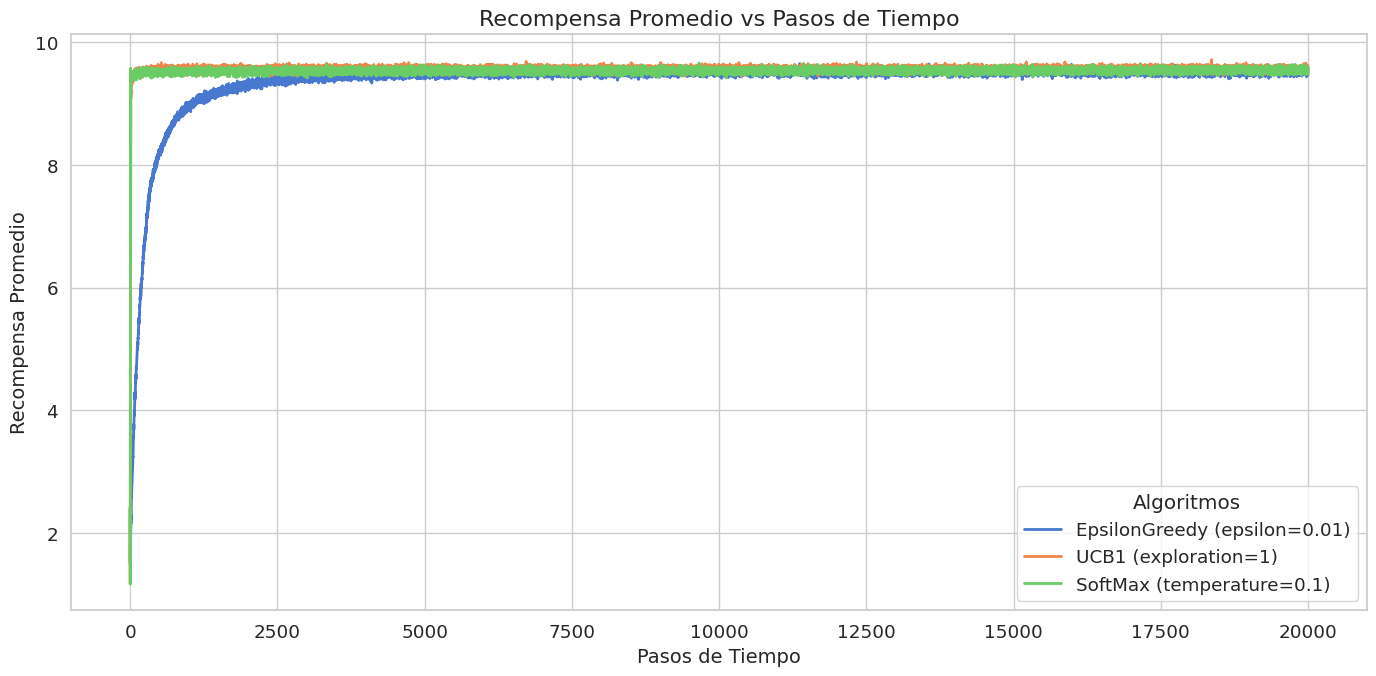

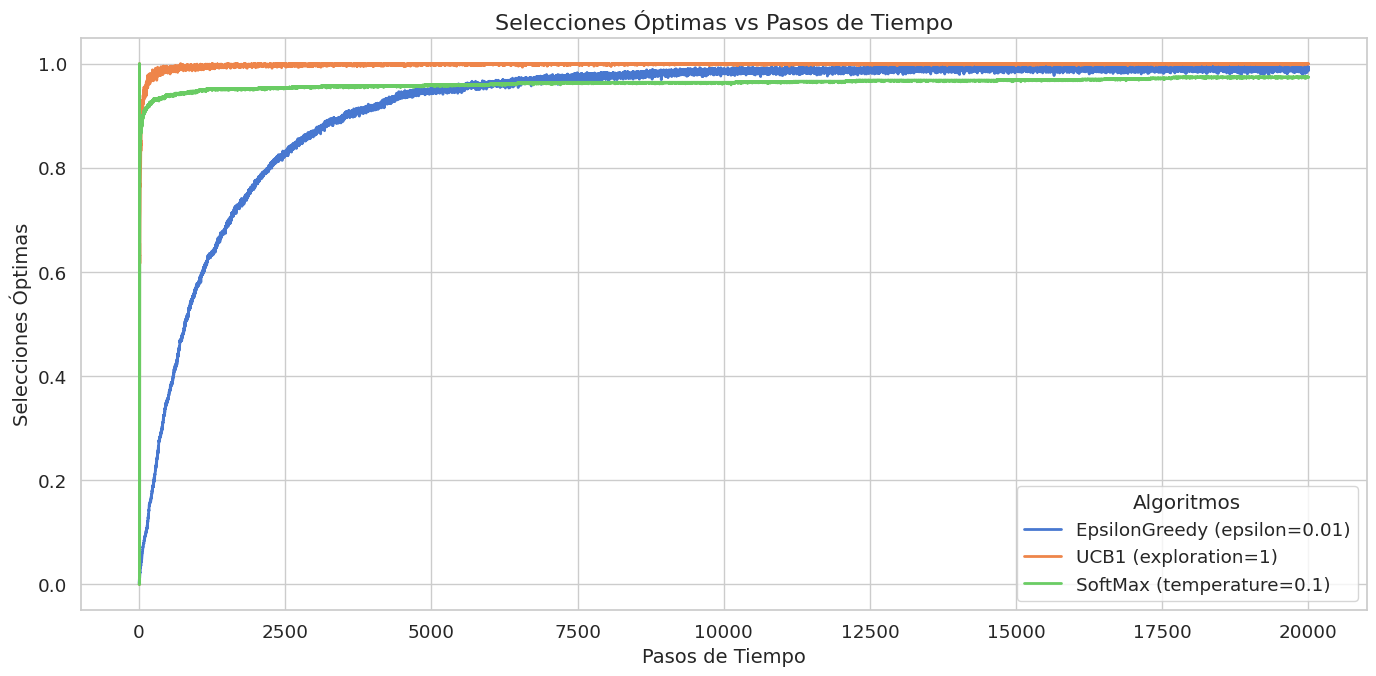

In [10]:
algorithms = [
    EpsilonGreedy(k=K, epsilon=0.01),
    UCB1(k=K, exploration=1),
    SoftMax(k=K, temperature=0.1)  
]

bandit_normal_s1 = Bandit(arms=ArmNormal.generate_arms(K, sigma=1)) 
optimal_arm_normal_s1 = bandit_normal_s1.optimal_arm

print(bandit_normal_s1)
print(f"Optimal arm: {optimal_arm_normal_s1 + 1} with expected reward={bandit_normal_s1.get_expected_value(optimal_arm_normal_s1)}")

rewards_normal_s1, optimal_selections_normal_s1, _, _ = run_experiment(bandit_normal_s1, algorithms, STEPS, RUNS)

plot_average_rewards(STEPS, rewards_normal_s1, algorithms, f"{SAVE_PLOTS_PATH}/normal_dist/sigma_1")
plot_optimal_selections(STEPS, optimal_selections_normal_s1, algorithms, f"{SAVE_PLOTS_PATH}/normal_dist/sigma_1")

Para la distribución normal con desviación estándar 1 el mejor es el algoritmo UCB1. En pocos pasos logra llegar a prácticamente el 100% de elecciones óptimas. Los demás algoritmos, aunque acaban consiguiendo resultados cercanos a los óptimos, se quedan detrás. El algoritmo $\epsilon$-Greedy consigue detectar el brazo óptimo, pero su exploración obligada le castiga en el porcentaje de selecciones óptimas. Los mismo ocurre con softmax con ligeros peores porcentajes.

Bandit with 10 arms: ArmNormal(mu=2.47, sigma=5), ArmNormal(mu=4.63, sigma=5), ArmNormal(mu=5.18, sigma=5), ArmNormal(mu=5.22, sigma=5), ArmNormal(mu=6.86, sigma=5), ArmNormal(mu=7.12, sigma=5), ArmNormal(mu=9.07, sigma=5), ArmNormal(mu=5.85, sigma=5), ArmNormal(mu=8.66, sigma=5), ArmNormal(mu=7.77, sigma=5)
Optimal arm: 7 with expected reward=9.07


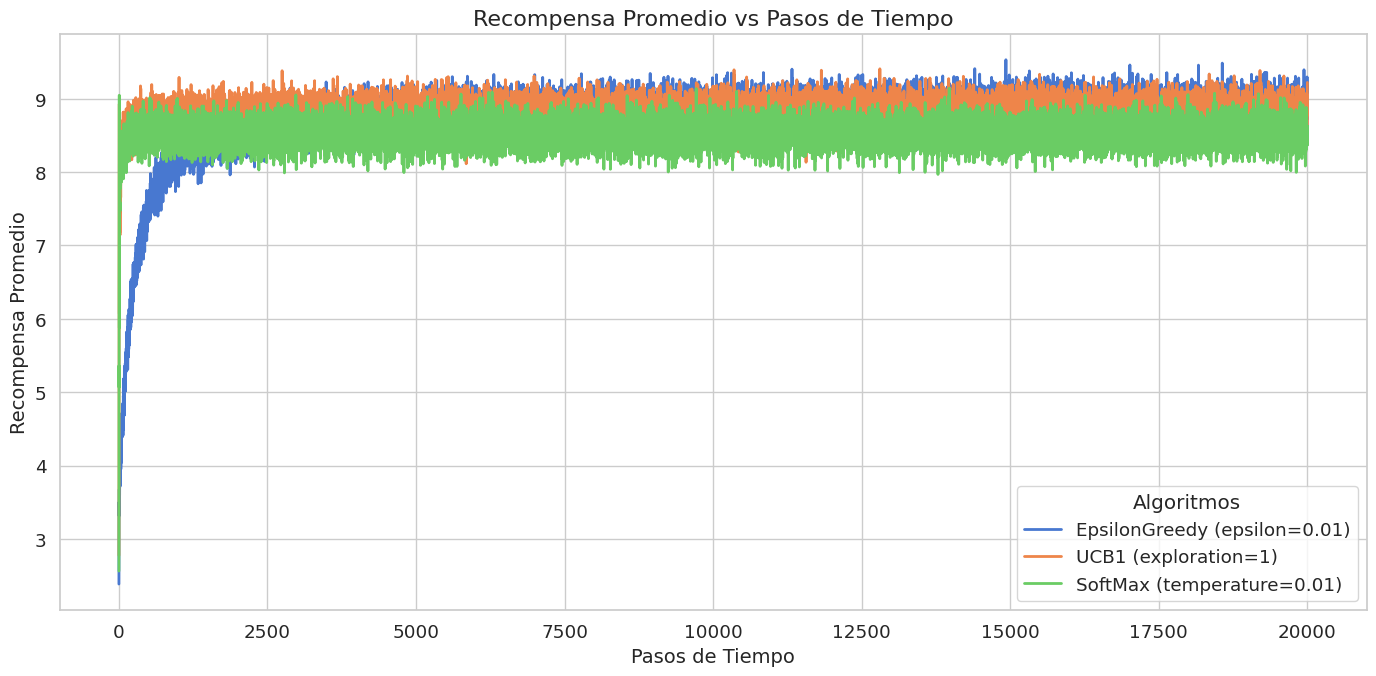

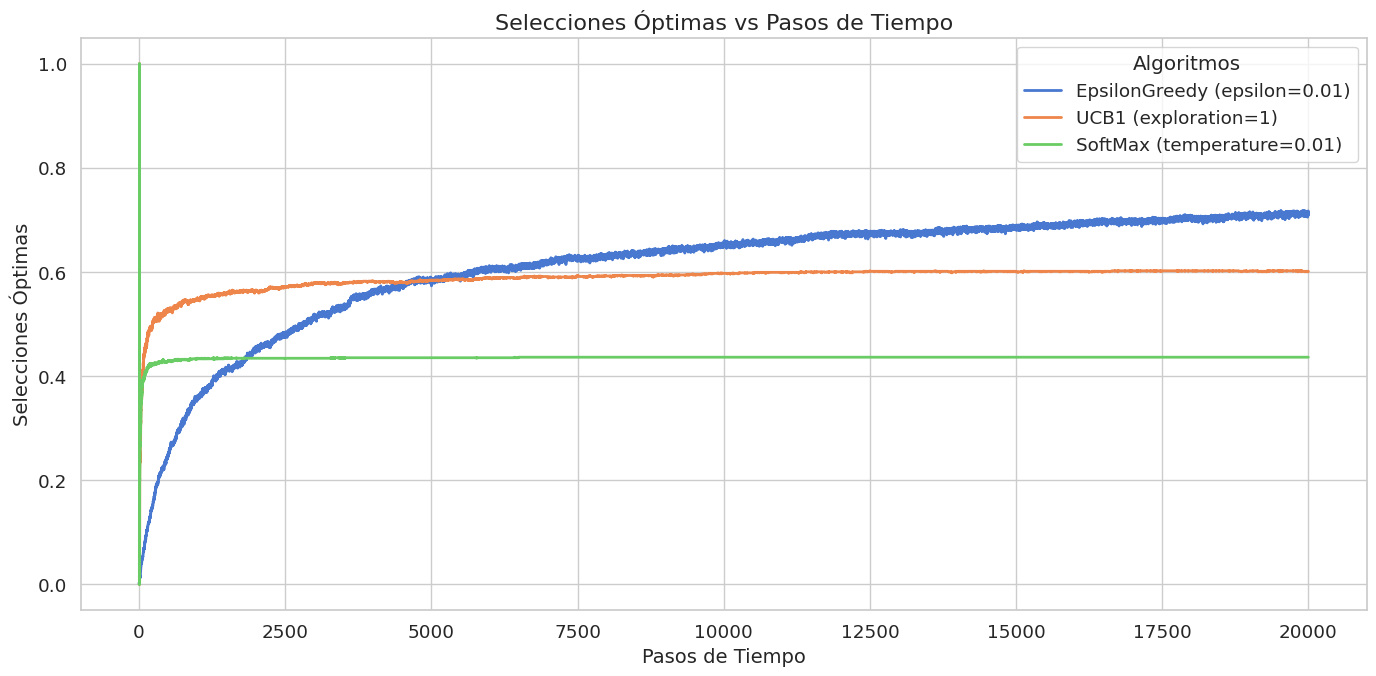

In [11]:
algorithms = [
    EpsilonGreedy(k=K, epsilon=0.01),
    UCB1(k=K, exploration=1),
    SoftMax(k=K, temperature=0.01)  
]

bandit_normal_s5 = Bandit(arms=ArmNormal.generate_arms(K, sigma=5))
optimal_arm_normal_s5 = bandit_normal_s5.optimal_arm

print(bandit_normal_s5)
print(f"Optimal arm: {optimal_arm_normal_s5 + 1} with expected reward={bandit_normal_s5.get_expected_value(optimal_arm_normal_s5)}")

rewards_normal_s5, optimal_selections_normal_s5, _, _ = run_experiment(bandit_normal_s5, algorithms, STEPS, RUNS)

plot_average_rewards(STEPS, rewards_normal_s5, algorithms, f"{SAVE_PLOTS_PATH}/normal_dist/sigma_5")
plot_optimal_selections(STEPS, optimal_selections_normal_s5, algorithms, f"{SAVE_PLOTS_PATH}/normal_dist/sigma_5")

Como experimentación adicional, se ha probado con una desviación estándar mayor: 5. Debido al aumento del ruido en las recompensas, todos los algoritmos tienen un peor desempeño. Destaca que el algoritmo $\epsilon$-Greedy termina con el mayor porcentaje de selecciones óptimas y además con tendencia ascendente. Esto se debe a la robustez ante el escalado de $\epsilon$-Greedy al mantener una probabilidad fija de exploración independientemente del ruido causado por la distribución. Por el contrario, UCB1 se estanca alrededor del 60% de soluciones óptimas y Softmax no supera el 45%.

### Distribución binomial

Bandit with 10 arms: ArmBinomial (n=100, p=0.58), ArmBinomial (n=100, p=0.37), ArmBinomial (n=100, p=0.89), ArmBinomial (n=100, p=0.29), ArmBinomial (n=100, p=0.5), ArmBinomial (n=100, p=0.23), ArmBinomial (n=100, p=0.57), ArmBinomial (n=100, p=0.76), ArmBinomial (n=100, p=0.88), ArmBinomial (n=100, p=0.69)
Optimal arm: 3 with expected reward=0.89


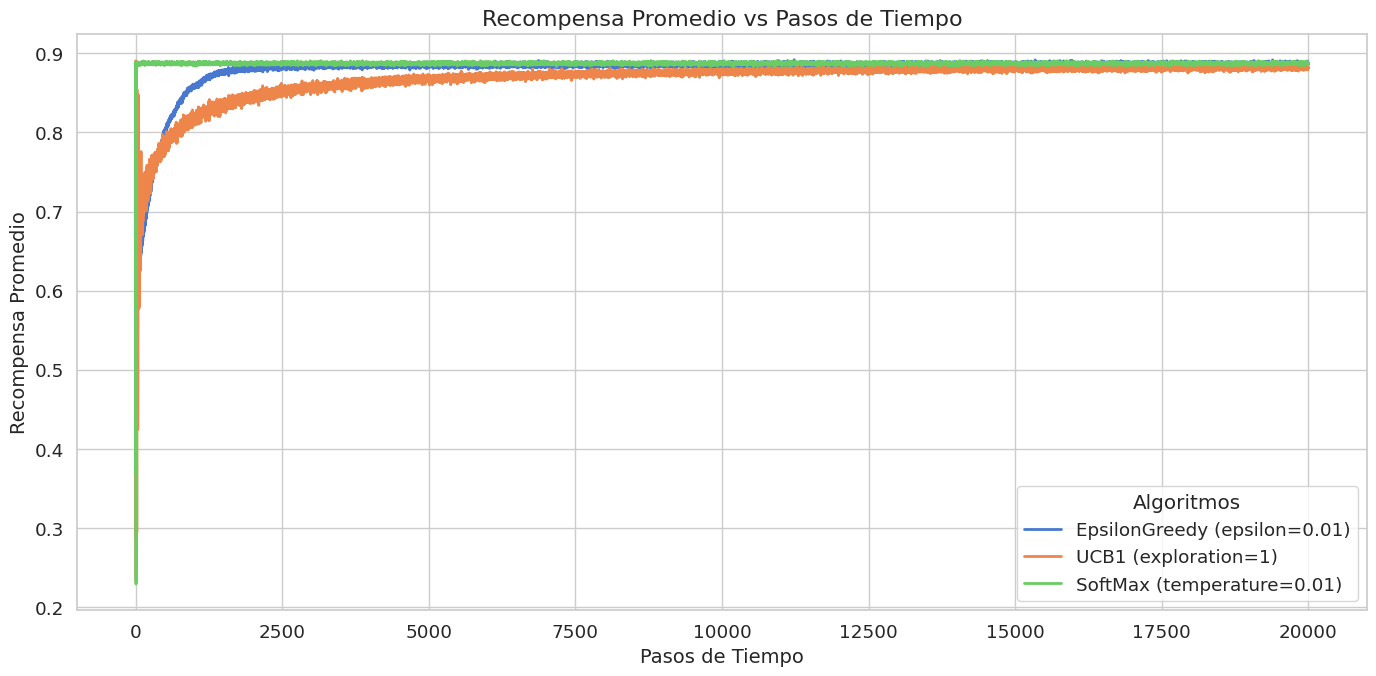

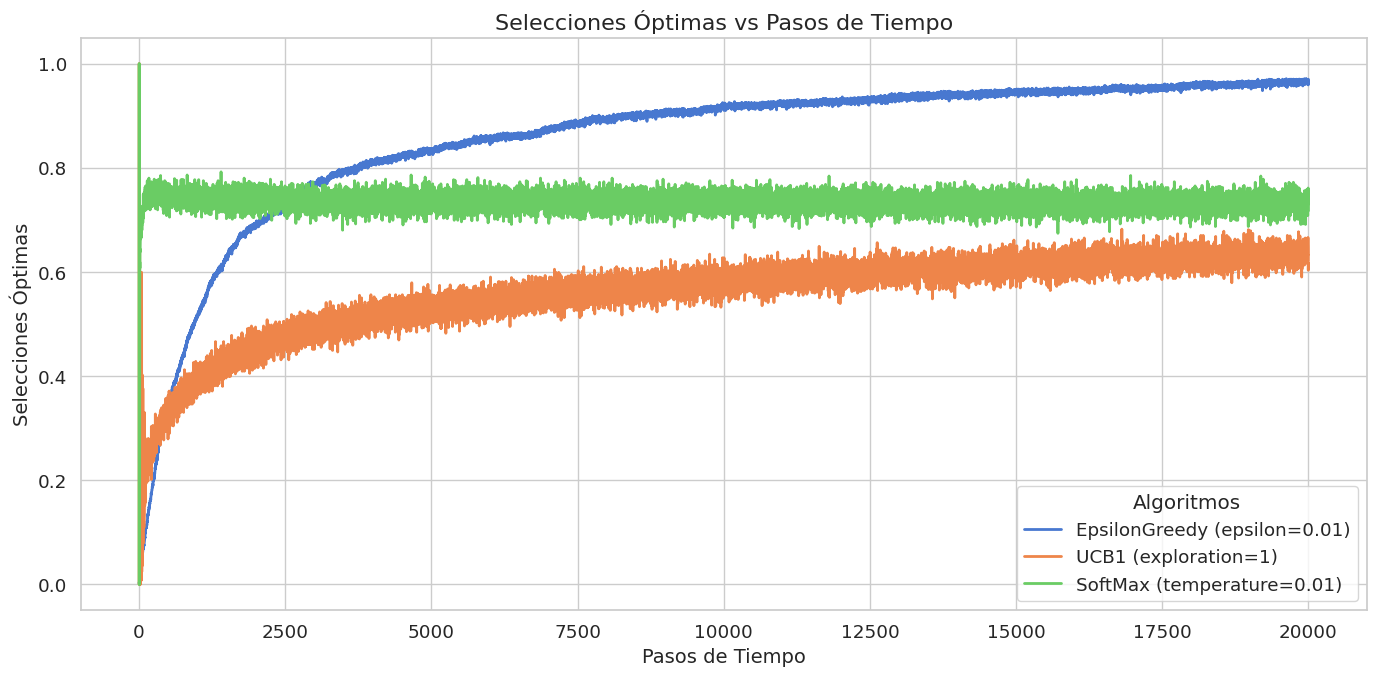

In [12]:
algorithms = [
    EpsilonGreedy(k=K, epsilon=0.01),
    UCB1(k=K, exploration=1),
    SoftMax(k=K, temperature=0.01)  
]

bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(K))
optimal_arm_binomial = bandit_binomial.optimal_arm

print(bandit_binomial)
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

rewards_binomial, optimal_selections_binomial, _, _ = run_experiment(bandit_binomial, algorithms, STEPS, RUNS)

plot_average_rewards(STEPS, rewards_binomial, algorithms, f"{SAVE_PLOTS_PATH}/binomial_dist")
plot_optimal_selections(STEPS, optimal_selections_binomial, algorithms, f"{SAVE_PLOTS_PATH}/binomial_dist")

En la gráfica binomial, todos los algoritmos sufren a la hora de seleccionar el brazo óptimo. Durante los pasos de tiempo, $\epsilon$-Greedy mejora su porcentaje de forma constante. Si siguiese la trayectoria actual, sería capaz de elegir el brazo óptimo con certeza. Softmax y UCB se estancan por debajo del 80% de selecciones óptimas, aunque la recompensa promedio es muy similar entre los 3 lo que indica que los mejores brazos tienen recompensas parecidas.

### Distribución de Bernoulli

Bandit with 10 arms: ArmBernoulli (np=0.81), ArmBernoulli (np=0.48), ArmBernoulli (np=0.88), ArmBernoulli (np=0.91), ArmBernoulli (np=0.84), ArmBernoulli (np=0.39), ArmBernoulli (np=0.68), ArmBernoulli (np=0.7), ArmBernoulli (np=0.23), ArmBernoulli (np=0.78)
Optimal arm: 4 with expected reward=0.91


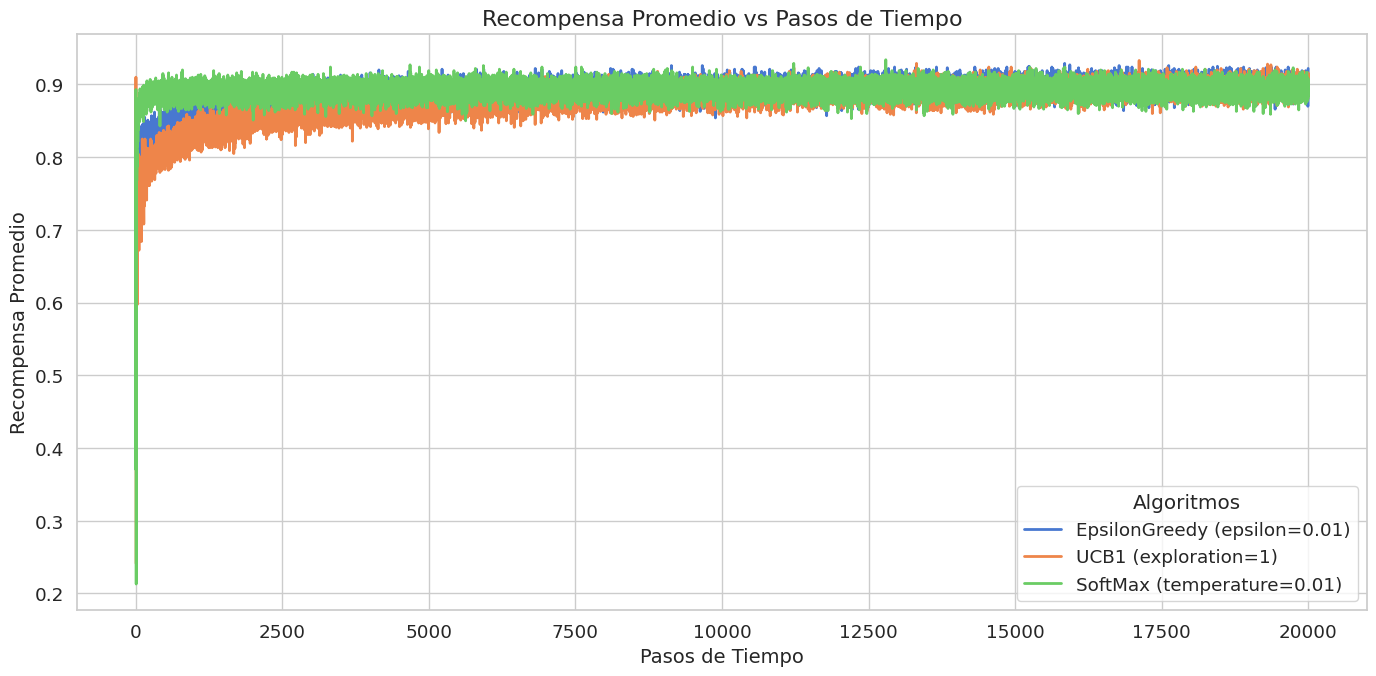

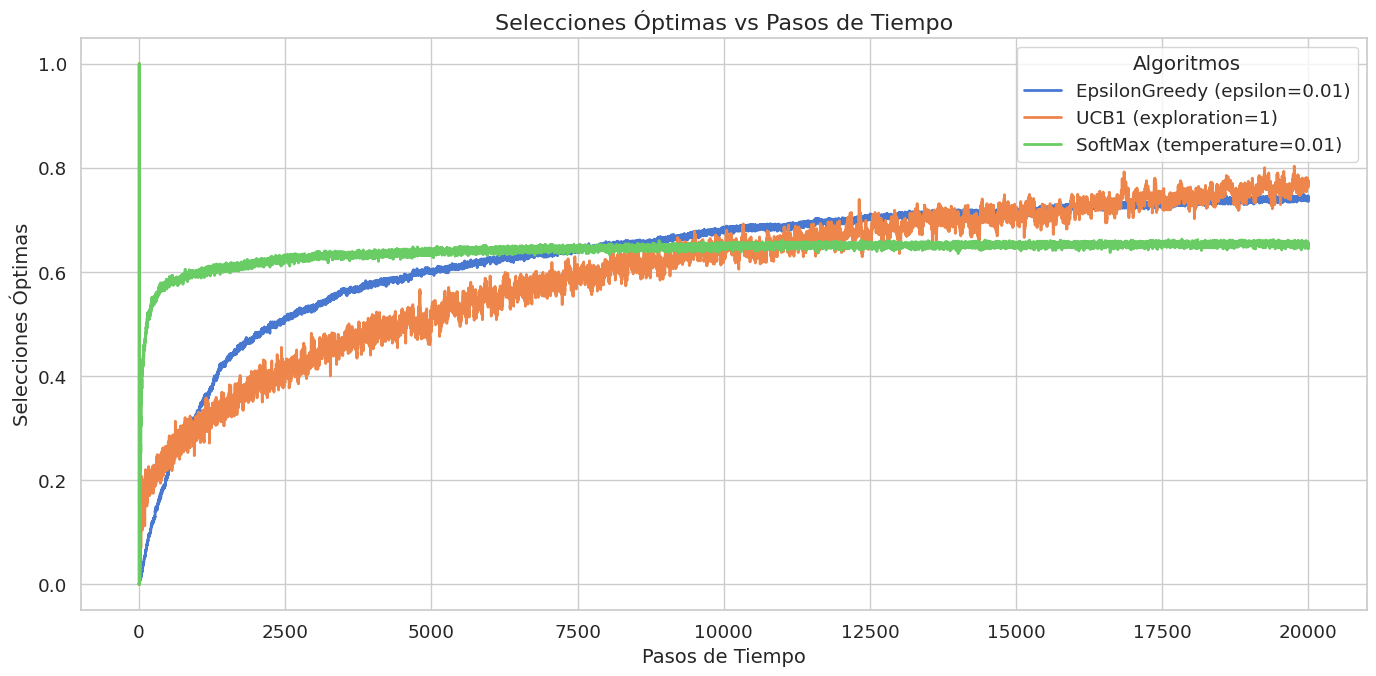

In [13]:
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(K))
optimal_arm_bernoulli = bandit_bernoulli.optimal_arm

print(bandit_bernoulli)
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

rewards_bernoulli, optimal_selections_bernoulli, _, _ = run_experiment(bandit_bernoulli, algorithms, STEPS, RUNS)

plot_average_rewards(STEPS, rewards_bernoulli, algorithms, f"{SAVE_PLOTS_PATH}/bernoulli_dist")
plot_optimal_selections(STEPS, optimal_selections_bernoulli, algorithms, f"{SAVE_PLOTS_PATH}/bernoulli_dist")

Con la distribución de Bernoulli, el algoritmo UCB1 aprende lento pero consistente durante la evolución del tiempo, lo que hace que al final de los 20.000 pasos sea el que mayor porcentaje de soluciones óptimas obtenga con casi el 80% con tendencia ascendente. De forma similar, $\epsilon$-Greedy consigue unos puntos porcentuales menos y con una curva de aprendizaje visiblemente más estancada, pero que continúa evolucionando. Al contrario, Softmax parece haber elegido en muchas de las ejecuciones un brazo subóptimo, lo que hace que se estanque en alrededor de un 60% de selecciones óptimas.

## Conclusión

Este experimento comparativo ha demostrado que, como en otros muchos casos, se aplica el teorema No Free Lunch, es decir, ningún algoritmo es el mejor para todos los casos. 

El algoritmo $\epsilon$-Greedy consigue buenos resultados en todas las pruebas, siendo su desventaja la probabilidad de exploración fija que no es mayor al inicio ni disminuye con el tiempo. Viendo su potencial, como trabajo futuro sería interesante estudiar su versión con decaimiento de epsilon.

En cuanto a UCB1, demuestra mejor desempeño en entornos de baja varianza, como la distribución normal con desviación estándar 1. Además, ha brillado en la distribución de Bernoulli, pues gracias a su componente exploratorio basado en la incertidumbre que prioriza los brazos menos utilizados, evita quedarse atrapado en una opción subóptima simplemente porque haya encadenado una racha de éxitos por encima de su media real debido al azar de una única tirada por paso de tiempo.

Finalmente, el algoritmo Softmax, aunque en cuanto a recompensa promedio sí obtiene buenos resultados, se queda detrás eligiendo el brazo óptimo. Haría falta ajustar más la temperatura para cada caso, pero los experimentos realizados muestran que tiene mayor dificultad para separar el brazo óptimo cuando otros tienen recompensas cercanas.

En conclusión, basado en este cuaderno, lo más seguro sería optar por el algoritmo $\epsilon$-Greedy con $\epsilon$=0.01 cuando se espera una distribución con alta varianza y UCB1 cuando se trabaja con varianzas más acotadas o distribuciones de Bernoulli.

Como futuro trabajo, investigar métodos de decaimiento de exploración ayudaría a obtener mejores resultados en ejecuciones de muchos pasos de tiempo como las planteadas en este trabajo.